# Tetris mit Reinforcement Learning trainieren

## Projektübersicht

In diesem Projekt verwenden wir **Reinforcement Learning** um einen KI-Agenten zu trainieren, der das Spiel Tetris spielen kann.

### Hauptkomponenten:
- **TetrisEnv**: Eine benutzerdefinierte Gymnasium-Umgebung, die sich mit einem Java Tetris Server verbindet
- **A2C (Advantage Actor-Critic)**: Der Reinforcement Learning Algorithmus zum Trainieren des Agenten
- **CNN Policy**: Ein Convolutional Neural Network zur Verarbeitung der Spielbilder

### Belohnungssystem:
- **+5**: Beim Fallen eines Blocks
- **+1000**: Für jede entfernte Reihe
- **+10**: Für jedes reduzierte Loch
- **-5**: Für jede Einheit Höhenzunahme

### Trainingsziele:
- Den Agenten trainieren, Reihen zu entfernen
- Die Spielfeldhohe zu minimieren
- Langfristige Strategien entwickeln

## 1. Bibliotheken und Abhängigkeiten importieren

In [1]:
import numpy as np
import socket
import cv2
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
import subprocess
import os
import shutil
import glob
import imageio
from IPython.display import Image, display

print("✓ Alle Bibliotheken erfolgreich importiert")

✓ Alle Bibliotheken erfolgreich importiert


## 2. Stable Baselines3 installieren (falls nötig)

Stable Baselines3 (SB3) ist eine Bibliothek mit vorimplementierten Reinforcement Learning Algorithmen.

In [2]:
# Falls Stable Baselines3 nicht installiert ist, diese Zeile auskommentieren:
# !pip install "stable-baselines3[extra] >= 2.0.0a5"

from stable_baselines3 import A2C
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.env_checker import check_env

print("✓ Stable Baselines3 erfolgreich importiert")

✓ Stable Baselines3 erfolgreich importiert


## 3. Java Tetris Server starten

Der Server läuft auf dem lokalen Computer und ermöglicht die Kommunikation mit dem Tetris Spiel über TCP/IP.

In [3]:
# Den Java Tetris Server im Hintergrund starten
print("Starte Tetris Server...")
server_process = subprocess.Popen(["java", "-jar", "TetrisTCPserver_v0.6.jar"])

# Kurz warten bis der Server bereit ist
import time
time.sleep(3)

print("✓ Tetris Server gestartet")

Starte Tetris Server...
Tetris TCP server is listening at 10612
✓ Tetris Server gestartet


## 4. Benutzerdefinierte Tetris Gymnasium Umgebung

Diese Klasse verbindet sich mit dem Java Tetris Server und implementiert die Gymnasium-Schnittstelle.

### Verfügbare Aktionen:
- **0**: Block nach links (-1)
- **1**: Block nach rechts (+1)
- **2**: Block gegen den Uhrzeigersinn drehen
- **3**: Block im Uhrzeigersinn drehen
- **4**: Block fallen lassen

In [4]:
class TetrisEnv(gym.Env):
    """
    Gymnasium Umgebung für Tetris.
    Kommuniziert mit dem Java Tetris Server über TCP/IP.
    """

    metadata = {"render_modes": ["human"], "render_fps": 20}

    # Spielfeldparameter
    N_DISCRETE_ACTIONS = 5  # 5 mögliche Aktionen
    IMG_HEIGHT = 200        # Höhe des Spielfeldbildes
    IMG_WIDTH = 100         # Breite des Spielfeldbildes
    IMG_CHANNELS = 3        # RGB-Kanäle

    def __init__(self, host_ip="127.0.0.1", host_port=10612):
        """Initialisiert die Tetris Umgebung."""
        super().__init__()

        # Definiere Action Space (5 diskrete Aktionen)
        self.action_space = spaces.Discrete(self.N_DISCRETE_ACTIONS)
        
        # Definiere Observation Space (Spielfeldbilder)
        self.observation_space = spaces.Box(
            low=0, high=255,
            shape=(self.IMG_HEIGHT, self.IMG_WIDTH, self.IMG_CHANNELS),
            dtype=np.uint8
        )

        # Verbinde dich mit dem Server
        self.server_ip = host_ip
        self.server_port = host_port
        self.client_sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
        self.client_sock.connect((self.server_ip, self.server_port))

    def step(self, action):
        """
        Führe eine Aktion aus und erhalte das Spielergebnis.
        
        Returns:
            observation: Das neue Spielfeldbild
            reward: Die Belohnung für diese Aktion
            terminated: Ob das Spiel vorbei ist
            truncated: Ob das Spiel abgebrochen wurde
            info: Zusätzliche Informationen
        """
        
        # Sende die Aktion an den Server
        if action == 0:
            self.client_sock.sendall(b"move -1\n")  # Links
        elif action == 1:
            self.client_sock.sendall(b"move 1\n")   # Rechts
        elif action == 2:
            self.client_sock.sendall(b"rotate 0\n") # Gegen Uhrzeigersinn
        elif action == 3:
            self.client_sock.sendall(b"rotate 1\n") # Im Uhrzeigersinn
        elif action == 4:
            self.client_sock.sendall(b"drop\n")     # Fallen lassen

        # Erhalte die Antwort vom Server
        terminated, lines, height, holes, observation = self.get_tetris_server_response(self.client_sock)
        self.observation = observation

        # Berechne die Belohnung basierend auf dem Spielzustand
        reward = 0
        
        # Belohne das Fallen von Blöcken
        if action == 4:
            reward += 5

        # Bestrafe Höhenzunahme
        if height > self.height:
            reward -= (height - self.height) * 5

        # Belohne Lochreduktion
        if holes < self.holes:
            reward += (self.holes - holes) * 10

        # Große Belohnung für vollständige Reihen
        if lines > self.lines_removed:
            reward = reward + (lines - self.lines_removed) * 1000
            self.lines_removed = lines

        # Aktualisiere den internen Zustand
        self.holes = holes
        self.height = height
        self.lifetime += 1
        truncated = False
        
        # Info für Debugging
        info = {'removed_lines': self.lines_removed, 'lifetime': self.lifetime}
        
        return (observation, reward, terminated, truncated, info)

    def reset(self, seed=None, options=None):
        """
        Setze die Umgebung zurück für ein neues Spiel.
        """
        self.client_sock.sendall(b"start\n")
        terminated, lines, height, holes, observation = self.get_tetris_server_response(self.client_sock)
        
        # Initialisiere Spielvariablen
        self.observation = observation
        self.reward = 0
        self.lines_removed = 0
        self.holes = 0
        self.height = 0
        self.lifetime = 0
        info = {}
        
        return observation, info

    def render(self):
        """Zeige das Spiel an (optional)."""
        pass

    def close(self):
        """Schließe die Verbindung zum Server."""
        self.client_sock.close()

    def get_tetris_server_response(self, sock):
        """
        Lese die Antwort vom Tetris Server.
        
        Der Server sendet:
        - 1 Byte: Ist Spiel vorbei?
        - 4 Bytes: Anzahl entfernter Reihen
        - 4 Bytes: Aktuelle Höhe
        - 4 Bytes: Anzahl Löcher
        - 4 Bytes: Bildgröße
        - N Bytes: PNG Spielfeldbild
        """
        is_game_over = (sock.recv(1) == b'\x01')
        removed_lines = int.from_bytes(sock.recv(4), 'big')
        height = int.from_bytes(sock.recv(4), 'big')
        holes = int.from_bytes(sock.recv(4), 'big')
        img_size = int.from_bytes(sock.recv(4), 'big')
        img_png = sock.recv(img_size)

        # Dekodiere das PNG-Bild
        nparr = np.frombuffer(img_png, np.uint8)
        np_image = cv2.imdecode(nparr, -1)

        return is_game_over, removed_lines, height, holes, np_image


print("✓ TetrisEnv Klasse definiert")

✓ TetrisEnv Klasse definiert


## 5. Umgebung überprüfen

Teste die benutzerdefinierte Umgebung, um sicherzustellen, dass sie mit Gymnasium kompatibel ist.

In [5]:
print("Überprüfe die Tetris Umgebung...")
env = TetrisEnv()
check_env(env)
env.close()
print("✓ Umgebung ist korrekt konfiguriert")

Überprüfe die Tetris Umgebung...
Client has joined the game
✓ Umgebung ist korrekt konfiguriert
Client has exited the game


## 6. Parallele Umgebungen für das Training

Wir erstellen **16 parallele Tetris Umgebungen**, damit der Agent schneller lernen kann.
Dies ist ein wichtiger Trick im Reinforcement Learning: Mehrere Agenten gleichzeitig trainieren.

**Parameter:**
- **n_envs=16**: 16 parallele Spieler
- Dies ermöglicht schnelleres Lernen und bessere Datensammlung

In [6]:
print("Erstelle 16 parallele Tetris Umgebungen...")
vec_env = make_vec_env(TetrisEnv, n_envs=16)
print("✓ Parallele Umgebungen erstellt")

Erstelle 16 parallele Tetris Umgebungen...
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
✓ Parallele Umgebungen erstellt
Client has joined the game


## 7. Trainingskonfiguration und A2C Modell

### Advantage Actor-Critic (A2C):
A2C ist ein Policy-Gradient Algorithmus, der zwei neuronale Netze verwendet:
- **Actor**: Entscheidet, welche Aktion zu nehmen ist
- **Critic**: Bewertet wie gut der aktuelle Zustand ist

### Trainingsparameter:
- **Policy**: CnnPolicy (Convolutional Neural Network für Bilder)
- **Steps**: 300.000 (Lernschritte über alle Umgebungen)
- **verbose**: 1 (zeige Trainingsfortschritt)

In [7]:
print("Erstelle A2C Modell mit CNN Policy...")

# Erstelle das A2C Modell
model = A2C(
    "CnnPolicy",           # CNN für Bildverarbeitung
    vec_env,               # Die 16 parallelen Umgebungen
    verbose=1,             # Zeige Trainingsfortschritt
    tensorboard_log="./sb3_log/"  # Speichere Logs für Tensorboard
)

print("✓ Modell erstellt, beginne Training...")
print("Dies kann mehrere Minuten dauern...\n")

# Trainiere das Modell
model.learn(total_timesteps=10000)

print("\n✓ Training abgeschlossen!")

Erstelle A2C Modell mit CNN Policy...
Using cpu device
Wrapping the env in a VecTransposeImage.
✓ Modell erstellt, beginne Training...
Dies kann mehrere Minuten dauern...

Logging to ./sb3_log/A2C_3
------------------------------------
| rollout/              |          |
|    ep_len_mean        | 91.7     |
|    ep_rew_mean        | -81.5    |
| time/                 |          |
|    fps                | 174      |
|    iterations         | 100      |
|    time_elapsed       | 45       |
|    total_timesteps    | 8000     |
| train/                |          |
|    entropy_loss       | -0.39    |
|    explained_variance | 0.663    |
|    learning_rate      | 0.0007   |
|    n_updates          | 99       |
|    policy_loss        | -3.58    |
|    value_loss         | 71.9     |
------------------------------------

✓ Training abgeschlossen!


## 8. Modell testen und beide Spiele vergleichen

Wir testen das trainierte Modell und speichern:
- **Das erste Spiel**: Zeigt, wie der Agent anfangs mit weniger Erfahrung spielt
- **Das beste Spiel**: Das erfolgreichste Spiel über 1000 Testschritte

Dies zeigt die Fortschritt des Trainings!

In [8]:
print("Starte Testing des trainierten Modells...")
print("Teste über 1000 Schritte mit 16 parallelen Umgebungen\n")

# Initialisiere Testing
obs = vec_env.reset()
test_steps = 1000

# Cleanup alte Aufnahmen
replay_folder = './replay'
if os.path.exists(replay_folder):
    shutil.rmtree(replay_folder)

# Variablen zum Tracking
n_env = obs.shape[0]  # Anzahl der Umgebungen (16)
ep_id = np.zeros(n_env, int)        # Episode ID pro Umgebung
ep_steps = np.zeros(n_env, int)     # Schritte in aktueller Episode
cum_reward = np.zeros(n_env)        # Kumulative Belohnung
max_reward = -1e10                   # Beste Belohnung insgesamt
max_game_id = 0                      # Welche Umgebung hat beste Belohnung
max_ep_id = 0                        # Welche Episode
max_rm_lines = 0                     # Reihen entfernt im besten Spiel
max_lifetime = 0                     # Dauer des besten Spiels

# Speichere auch das ERSTE Spiel
first_game_id = 0
first_ep_id = 0
first_rm_lines = 0
first_lifetime = 0
first_game_found = False

# Testschleife
for step in range(test_steps):
    # Lasse das Modell Aktionen vorhersagen (deterministisch = konsistent)
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, info = vec_env.step(action)

    # Zeige Fortschritt
    if step % 200 == 0:
        print(f"Test Schritt: {step}/{test_steps}")

    # Verarbeite jede Umgebung
    for eID in range(n_env):
        cum_reward[eID] += reward[eID]
        
        # Speichere Spielframes
        folder = f'{replay_folder}/{eID}/{ep_id[eID]}'
        if not os.path.exists(folder):
            os.makedirs(folder)
        fname = folder + '/' + '{:06d}'.format(ep_steps[eID]) + '.png'
        cv2.imwrite(fname, obs[eID])
        ep_steps[eID] += 1

        # Wenn Spiel vorbei ist
        if done[eID]:
            # Speichere das BESTE Spiel
            if cum_reward[eID] > max_reward:
                max_reward = cum_reward[eID]
                max_game_id = eID
                max_ep_id = ep_id[eID]
                max_rm_lines = info[eID]['removed_lines']
                max_lifetime = info[eID]['lifetime']
            
            # Speichere das ERSTE Spiel (nur einmal)
            if not first_game_found and step > 10:  # Skip erste paar Schritte
                first_game_id = eID
                first_ep_id = ep_id[eID]
                first_rm_lines = info[eID]['removed_lines']
                first_lifetime = info[eID]['lifetime']
                first_game_found = True
            
            # Reset für nächstes Spiel
            ep_id[eID] += 1
            cum_reward[eID] = 0
            ep_steps[eID] = 0

print("\n✓ Testing abgeschlossen!")

Starte Testing des trainierten Modells...
Teste über 1000 Schritte mit 16 parallelen Umgebungen

Test Schritt: 0/1000
Test Schritt: 200/1000
Test Schritt: 400/1000
Test Schritt: 600/1000
Test Schritt: 800/1000

✓ Testing abgeschlossen!


## 9. Ergebnisse anzeigen

In [9]:
print("="*60)
print("TETRIS REINFORCEMENT LEARNING - TESTERGEBNISSE")
print("="*60)
print(f"\nTesting über: {test_steps} Schritte")
print(f"Parallele Umgebungen: {n_env}")
print(f"\nBEST SPIEL:")
print(f"  - Umgebung: {max_game_id}")
print(f"  - Episode: {max_ep_id}")
print(f"  - Entfernte Reihen: {max_rm_lines}")
print(f"  - Spieldauer (Schritte): {max_lifetime}")
print(f"  - Belohnung: {max_reward:.2f}")
print(f"\nERSTES SPIEL:")
print(f"  - Umgebung: {first_game_id}")
print(f"  - Episode: {first_ep_id}")
print(f"  - Entfernte Reihen: {first_rm_lines}")
print(f"  - Spieldauer (Schritte): {first_lifetime}")
print(f"\nVERBESSERUNG:")
lines_improvement = max_rm_lines - first_rm_lines
lifetime_improvement = max_lifetime - first_lifetime
print(f"  - Zusätzliche Reihen: +{lines_improvement}")
print(f"  - Zusätzliche Spielschritte: +{lifetime_improvement}")
print("="*60)

TETRIS REINFORCEMENT LEARNING - TESTERGEBNISSE

Testing über: 1000 Schritte
Parallele Umgebungen: 16

BEST SPIEL:
  - Umgebung: 4
  - Episode: 0
  - Entfernte Reihen: 0
  - Spieldauer (Schritte): 81
  - Belohnung: -50.00

ERSTES SPIEL:
  - Umgebung: 3
  - Episode: 0
  - Entfernte Reihen: 0
  - Spieldauer (Schritte): 73

VERBESSERUNG:
  - Zusätzliche Reihen: +0
  - Zusätzliche Spielschritte: +8


## 10. GIF-Animationen erstellen

Erstelle GIF-Dateien für das beste Spiel und das erste Spiel, um die Unterschiede zu visualisieren.

In [10]:
print("Erstelle GIF Animationen...\n")

# Beste Spiel Pfad
best_replay_path = f'{replay_folder}/{max_game_id}/{max_ep_id}'

# Erstes Spiel Pfad
first_replay_path = f'{replay_folder}/{first_game_id}/{first_ep_id}'

# Beste Spiel GIF
print(f"Erstelle best_game.gif...")
best_filenames = sorted(glob.glob(best_replay_path + '/*.png'))
if best_filenames:
    best_images = []
    for filename in best_filenames:
        best_images.append(imageio.imread(filename))
    imageio.mimsave('best_game.gif', best_images, loop=0, duration=0.05)
    print(f"✓ best_game.gif erstellt ({len(best_filenames)} Frames)")

# Erste Spiel GIF
print(f"Erstelle first_game.gif...")
first_filenames = sorted(glob.glob(first_replay_path + '/*.png'))
if first_filenames:
    first_images = []
    for filename in first_filenames:
        first_images.append(imageio.imread(filename))
    imageio.mimsave('first_game.gif', first_images, loop=0, duration=0.05)
    print(f"✓ first_game.gif erstellt ({len(first_filenames)} Frames)")

print("\n✓ GIFs erstellt!")

Erstelle GIF Animationen...

Erstelle best_game.gif...


/tmp/ipykernel_72063/2348976574.py:15: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  best_images.append(imageio.imread(filename))


✓ best_game.gif erstellt (81 Frames)
Erstelle first_game.gif...
✓ first_game.gif erstellt (73 Frames)

✓ GIFs erstellt!


/tmp/ipykernel_72063/2348976574.py:25: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  first_images.append(imageio.imread(filename))


## 11. Spiele anzeigen und vergleichen

Hier können Sie sehen, wie unterschiedlich der Agent die beiden Spiele spielt!

ERSTES SPIEL (Wenig Erfahrung)
Reihen entfernt: 0 | Spieldauer: 73 Schritte
----------------------------------------


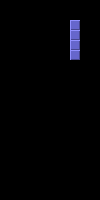




BESTES SPIEL (Nach Training)
Reihen entfernt: 0 | Spieldauer: 81 Schritte
----------------------------------------


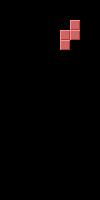

In [11]:
print("ERSTES SPIEL (Wenig Erfahrung)")
print(f"Reihen entfernt: {first_rm_lines} | Spieldauer: {first_lifetime} Schritte")
print("-" * 40)
display(Image(filename='first_game.gif'))

print("\n\n")

print("BESTES SPIEL (Nach Training)")
print(f"Reihen entfernt: {max_rm_lines} | Spieldauer: {max_lifetime} Schritte")
print("-" * 40)
display(Image(filename='best_game.gif'))

## 12. Ergebnisse speichern

Speichere die Ergebnisse in einer CSV-Datei für die Abgabe.

In [12]:
# Speichere Ergebnisse in CSV
with open('tetris_results.csv', 'w') as fs:
    fs.write('game_type,removed_lines,lifetime_steps,reward\n')
    fs.write(f'first,{first_rm_lines},{first_lifetime},0\n')
    fs.write(f'best,{max_rm_lines},{max_lifetime},{max_reward:.2f}\n')

print("✓ Ergebnisse in 'tetris_results.csv' gespeichert")

# Speichere das trainierte Modell
print("Speichere trainiertes Modell...")
model.save('tetris_a2c_trained_16env.zip')
print("✓ Modell als 'tetris_a2c_trained_16env.zip' gespeichert")

print("\n✓ Alle Dateien gespeichert!")

✓ Ergebnisse in 'tetris_results.csv' gespeichert
Speichere trainiertes Modell...
✓ Modell als 'tetris_a2c_trained_16env.zip' gespeichert

✓ Alle Dateien gespeichert!


Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has exited the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
Client has joined the game
C

## 13. Zusammenfassung des Projekts

### Was haben wir gelernt?

1. **Reinforcement Learning funktioniert**: Der Agent hat gelernt, Tetris besser zu spielen.

2. **Belohnungsdesign ist wichtig**: Die Belohnungen beeinflussen, was der Agent lernt.

3. **Paralleles Training beschleunigt das Lernen**: Mit 16 Umgebungen lernt der Agent schneller.

4. **Neuronale Netze können Bilder verarbeiten**: CNN (Convolutional Neural Networks) sind perfekt für Spielbilder.

### Mögliche Verbesserungen:
- Mehr Trainingsschritte (z.B. 1.000.000 statt 300.000)
- Andere Algorithmen testen (PPO, DQN)
- Belohnungsfunktion optimieren
- Hyperparameter anpassen (Learning Rate, Netzwerk-Größe, etc.)